# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [2]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT Course/Project 1/Customer_Personality_Segmentation.csv", sep="\t")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [4]:
# creating a copy of the data
data = data.copy()

## **Data Overview**

#### Viewing the first and last 5 rows of the dataset

In [5]:
data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [6]:
data.tail(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


#### Calculating the age of the customer using the "Year Birth"

In [7]:
from datetime import datetime

# Get the current year
current_year = datetime.now().year

# Calculate the age of the customer
data['Age'] = current_year - data['Year_Birth']

In [8]:
data.shape

(2240, 30)

- The dataset has 2240 rows and 30 columns.

#### **Question 1**: What are the data types of all the columns?

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### **Observations from data.info():**
- The dataset contains **2240 entries** and **30 columns**.
- **Data Types:**
    - **Integer int64:** 26 columns, including IDs, birth year, spending amounts MntWines, etc., and campaign responses.
    - **Float float64:** Only 1 column, **Income**, which also contains 24 missing values.
    - **Object string:** 3 columns: **Education**, **Marital_Status**, and **Dt_Customer** which represents the enrollment date.
- **Missing Values:** Only the **Income** column has missing values 2216 non-null out of 2240.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [10]:
# Get the summary statistics of the numerical data
data.describe() ## Write the appropriate function to print the statitical summary of the data

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000


#### **Observations from data.describe():**
- **Average Household Income:** The mean income is approximately **$52,247**, though there is a high standard deviation and a maximum value suggesting potential outliers.
- **Age:** The average customer age is around 57-58 years based on current year calculations.
- **Spending Habits:**
    - **Wines** and **Meat Products** are the categories with the highest average spending ~304 and ~167 respectively.
    - **Fruits** and **Sweets** have the lowest average spending ~26 and ~27.
- **Household Composition:** On average, customers have roughly **0.44 children** and **0.50 teenagers** at home.
- **Shopping Channels:** Customers prefer **Store Purchases** mean ~5.8 over **Web Purchases** mean ~4.1 and **Catalog Purchases** mean ~2.7.

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [12]:
# Checking for missing values in the data
data.isnull().sum()  #Write the appropriate function to print the sum of null values for each column

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


#### **Observations from data.isnull.sum:**
- The **Income** column is the only variable with missing data, containing **24 null values**.
- All other columns have **0 null values**, meaning the rest of the dataset is complete.
- These 24 missing values represent a small fraction of the total 2240 entries but should be handled before further analysis.

#### **Question 4**: Are there any duplicates in the data?

In [13]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

#### **Observations from data.duplicated.sum:**
- The duplicate check returned a value of 0
- This indicates that there are no identical rows in the dataset
- Every record in the data is unique based on all combined attributes

### Dropping columns which are irrelevant to our analysis.

In [14]:
columns_to_drop = ['Dt_Customer','Year_Birth','ID','AcceptedCmp1', 'Z_CostContact', 'Z_Revenue', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Education', 'Marital_Status']
data.drop(columns=columns_to_drop, inplace=True)

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

In [15]:
data.shape

(2240, 18)

#### PLotting the histogram of each column.

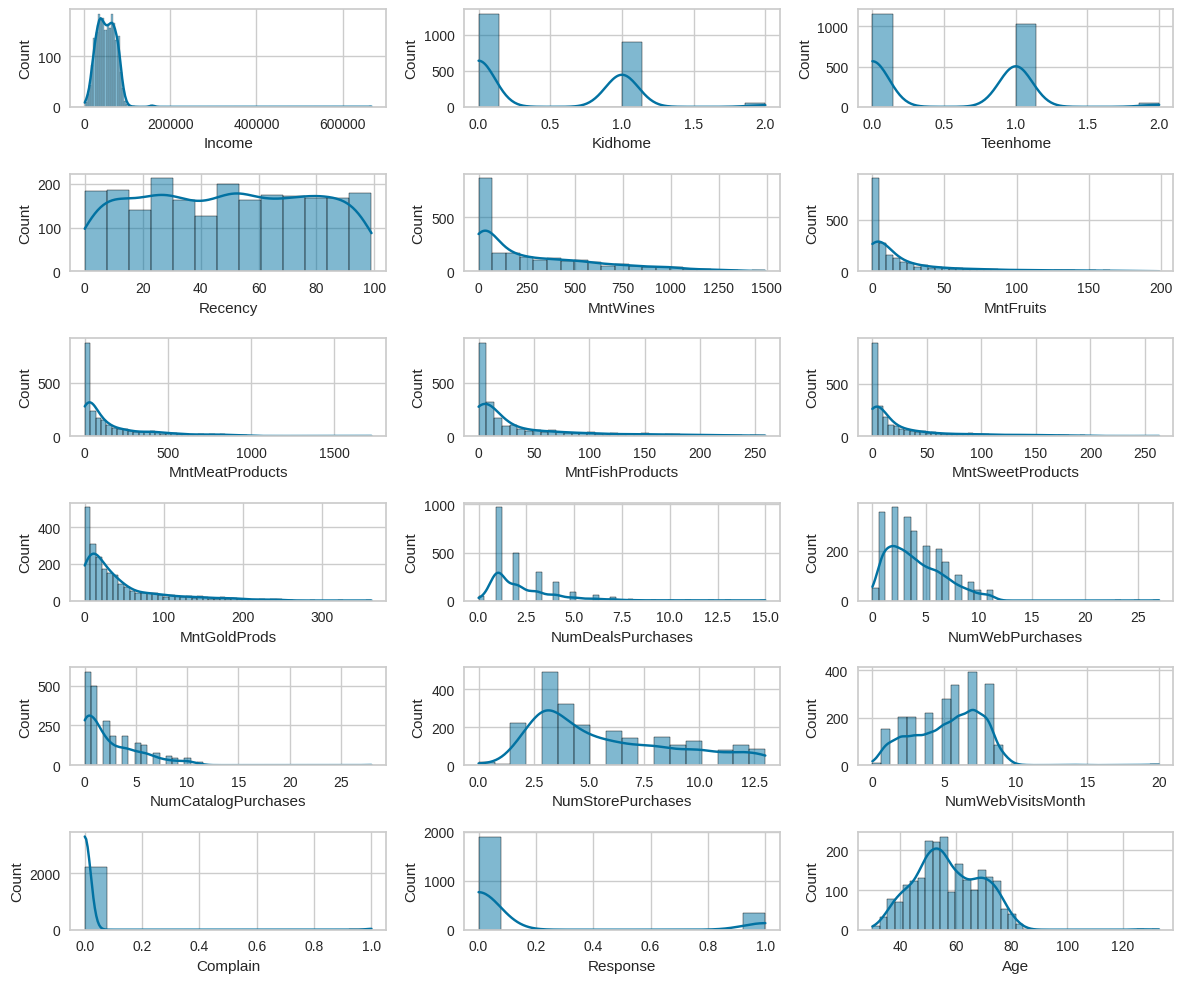

In [16]:
# defining the figure size
plt.figure(figsize=(12, 10))

for i, feature in enumerate(data.columns): #iterating through each column
    plt.subplot(6, 3, i+1)                  # assign a subplot in the main plot
    sns.histplot(data=data, x=feature, kde = True)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

#### PLotting the boxplot of each column.

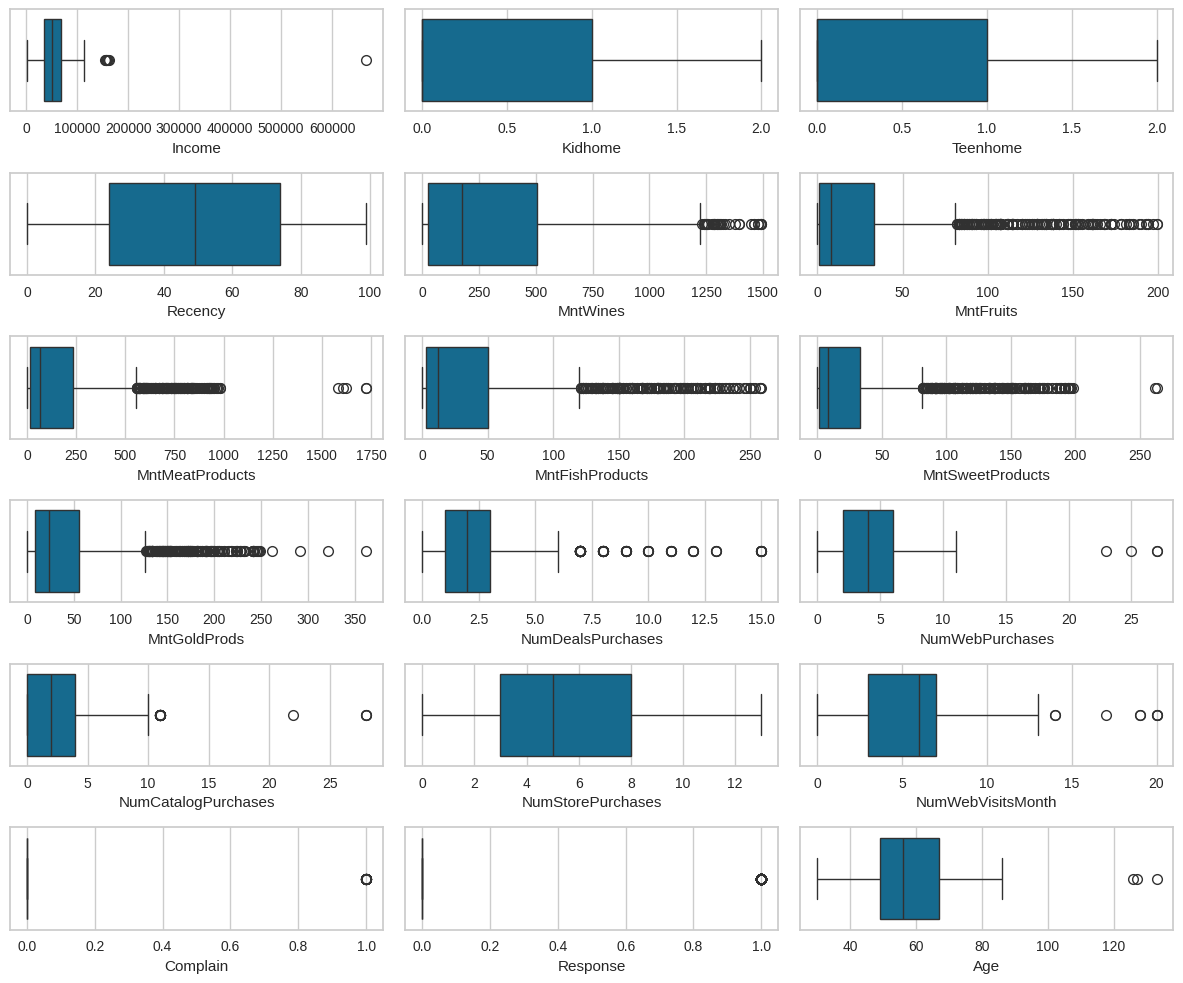

In [19]:
# defining the figure size
plt.figure(figsize=(12, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(data.columns):    # iterating through each column
    plt.subplot(6, 3, i+1)                     # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the boxplot

plt.tight_layout();   # to add spacing between plots

#### **Observations from Univariate Analysis:**
- **Spending Variables:** Features like MntWines, MntFruits, and MntMeatProducts show a strong right-skewed distribution. Most customers spend smaller amounts, while a few high-value customers spend significantly more.
- **Income:** The income distribution is roughly normal but shows some extreme outliers on the higher end.
- **Age:** The age distribution is relatively balanced, with most customers falling into the middle-aged or older categories.
- **Purchases:** Store purchases are the most common channel, while catalog purchases are the least frequent.
- **Outliers:** Boxplots reveal several outliers in Income and almost all spending categories, which is common in retail data due to varying customer wealth and shopping habits.

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

**Let's check for correlations.**

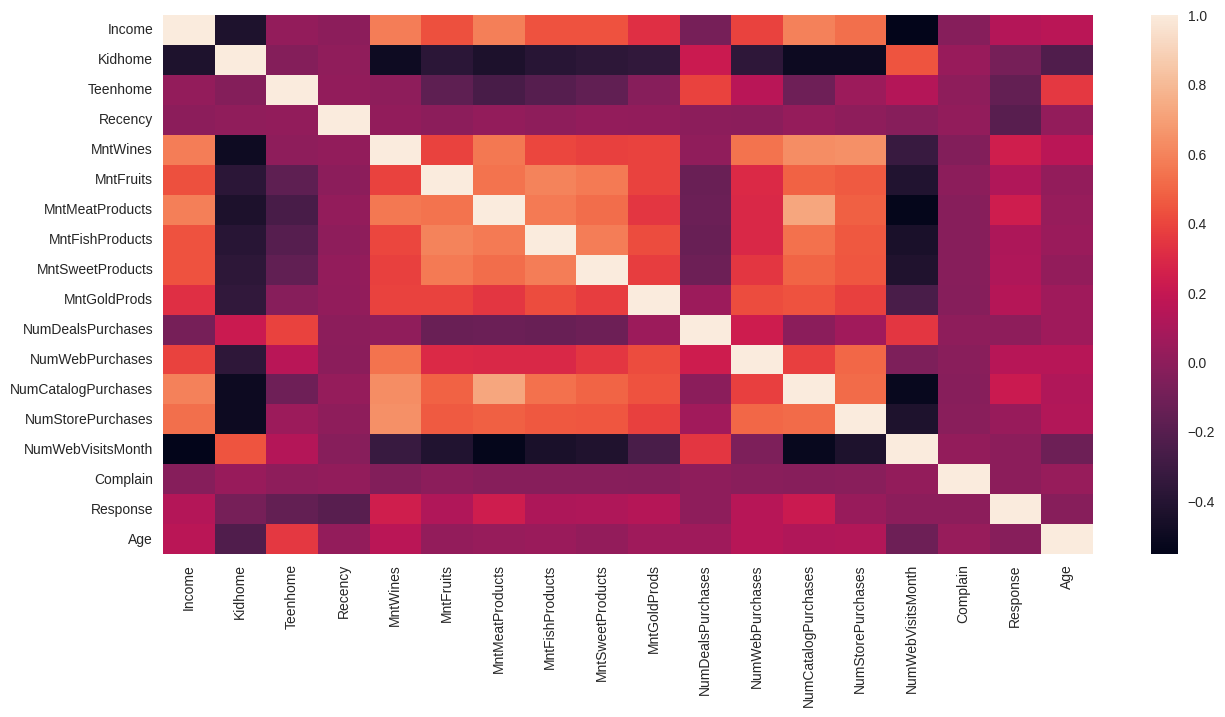

In [20]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr())
plt.show()

**Let's check for pairplots.**

In [22]:
sns.pairplot(data=data, diag_kind="kde")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#### **Observations from Multivariate Analysis:**
- **Income and Spending:** There is a strong positive correlation between Income and spending on luxury items like MntWines and MntMeatProducts. Higher income levels generally lead to higher overall expenditure.
- **Purchase Channels:** Positive correlations exist between the number of Store, Catalog, and Web purchases. This suggests that high-value customers tend to be active across multiple shopping channels.
- **Family Structure:** Kidhome and Teenhome show a negative correlation with spending on Wines and Meat. This indicates that households with more children or teenagers may prioritize different spending categories or have less disposable income for luxury goods.
- **Website Activity:** NumWebVisitsMonth is negatively correlated with Income and most spending categories. This suggests that while lower-income customers visit the site frequently, they may be browsing for deals rather than making high-value purchases.

## **Data Preprocessing**

### Scaling

- Let's scale the data before we proceed with clustering.

In [23]:
# scaling the data before clustering
scaler = StandardScaler()
subset = data.copy()
subset_scaled = scaler.fit_transform(subset)

In [24]:
# creating a dataframe of the scaled data
subset_scaled_data = pd.DataFrame(subset_scaled, columns=subset.columns)

## **K-means Clustering**

In [25]:
k_means_data = subset_scaled_data.copy() # Do not change this code. This will be used later in cluster profiling

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

Number of Clusters: 2 	WCSS: 29884.281355683233
Number of Clusters: 3 	WCSS: 26221.590839859084
Number of Clusters: 4 	WCSS: 24439.14868661552
Number of Clusters: 5 	WCSS: 23453.497592242617
Number of Clusters: 6 	WCSS: 22598.38357236641
Number of Clusters: 7 	WCSS: 21784.6191358619
Number of Clusters: 8 	WCSS: 19701.003700066605
Number of Clusters: 9 	WCSS: 19359.422920940255
Number of Clusters: 10 	WCSS: 18693.27425769855


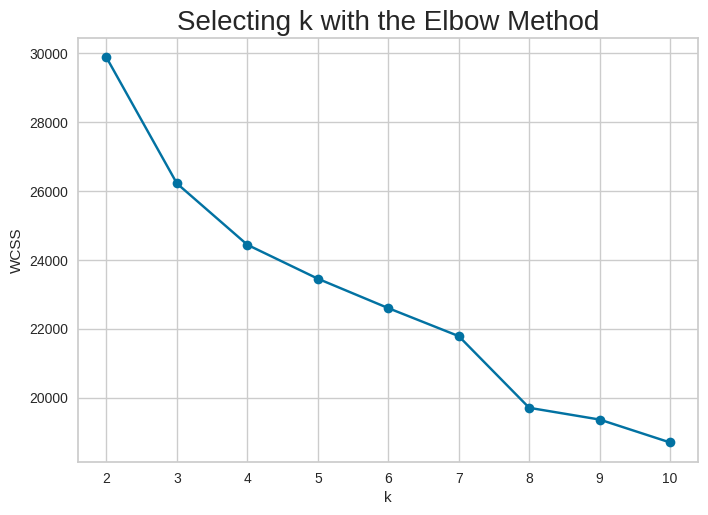

In [32]:
clusters = range(2, 11)
wcss_k8 = []

k_means_data = k_means_data.dropna() # Handle missing values by dropping rows with NaN

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1) # initialize the kmeans model
    model.fit(k_means_data) # fit the kmeans model on the scaled data.
    wcss = model.inertia_
    wcss_k8.append(wcss)

    print("Number of Clusters:", k, "\tWCSS:",wcss)

plt.plot(clusters, wcss_k8, "bx-", marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

#### **Observations from the Elbow Plot:**
- The Within-Cluster Sum of Squares WCSS decreases as the number of clusters increases.
- A visible bend or elbow can be observed at k=3 and k=4.
- Beyond k=4, the reduction in WCSS becomes less significant, suggesting that 4 clusters might be an appropriate choice for this dataset.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

In [28]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)       # initialize the kmeans model with the number o clusters.
    preds = clusterer.fit_predict((k_means_data))                  # Fit the kmeans model
    score = silhouette_score(k_means_data, preds)             # Check the silhoutte score against the predictions
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.28404986573465846)
For n_clusters = 3, the silhouette score is 0.21233779497170222)
For n_clusters = 4, the silhouette score is 0.22250531287477177)
For n_clusters = 5, the silhouette score is 0.1887517880468877)
For n_clusters = 6, the silhouette score is 0.1957071772552416)
For n_clusters = 7, the silhouette score is 0.13982335504789795)
For n_clusters = 8, the silhouette score is 0.1546126641260676)
For n_clusters = 9, the silhouette score is 0.15344302613117153)


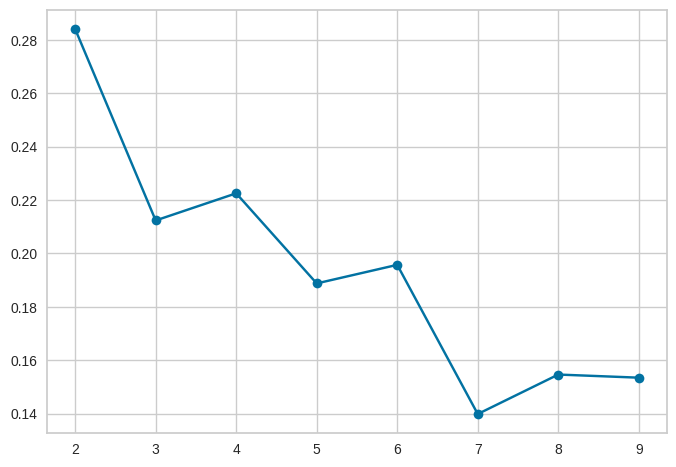

In [29]:
plt.plot(cluster_list, sil_score, marker = 'o')
plt.show()

#### **Observations from Silhouette Scores:**
- The highest silhouette score is observed at n_clusters = 2 with a value of approximately 0.28.
- There is a slight peak at n_clusters = 4 with a score of approximately 0.22, which aligns with the elbow observed in the previous plot.
- As the number of clusters increases beyond 4, the silhouette score generally decreases or remains low, suggesting that a smaller number of clusters is more appropriate for this data.
- Both the elbow method and the silhouette score support choosing 4 clusters to achieve a balance between model complexity and cluster distinctness.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [30]:
%%time
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(k_means_data)

CPU times: user 9.05 ms, sys: 16 µs, total: 9.06 ms
Wall time: 9.4 ms


KMeans(n_clusters=4, random_state=0)

#### **Observations from the Final Fit:**
- The K-Means model with 4 clusters was successfully fitted to the scaled data.
- The execution was extremely fast, taking only about 9 to 10 milliseconds for the CPU to process the clusters.
- This indicates that the algorithm is highly efficient for a dataset containing 2216 records and 18 features.

In [33]:
# creating a copy of the original data
data1 = data.copy()

# Drop rows with NaN values from data1 to match the k_means_data that was used for clustering
data1.dropna(inplace=True)

# adding kmeans cluster labels to the original and scaled dataframes
k_means_data["K_means_segments"] = kmeans.labels_
data1["K_means_segments"] = kmeans.labels_

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

**Let's create some plots on the original data to understand the customer distribution among the clusters in Kmeans.**

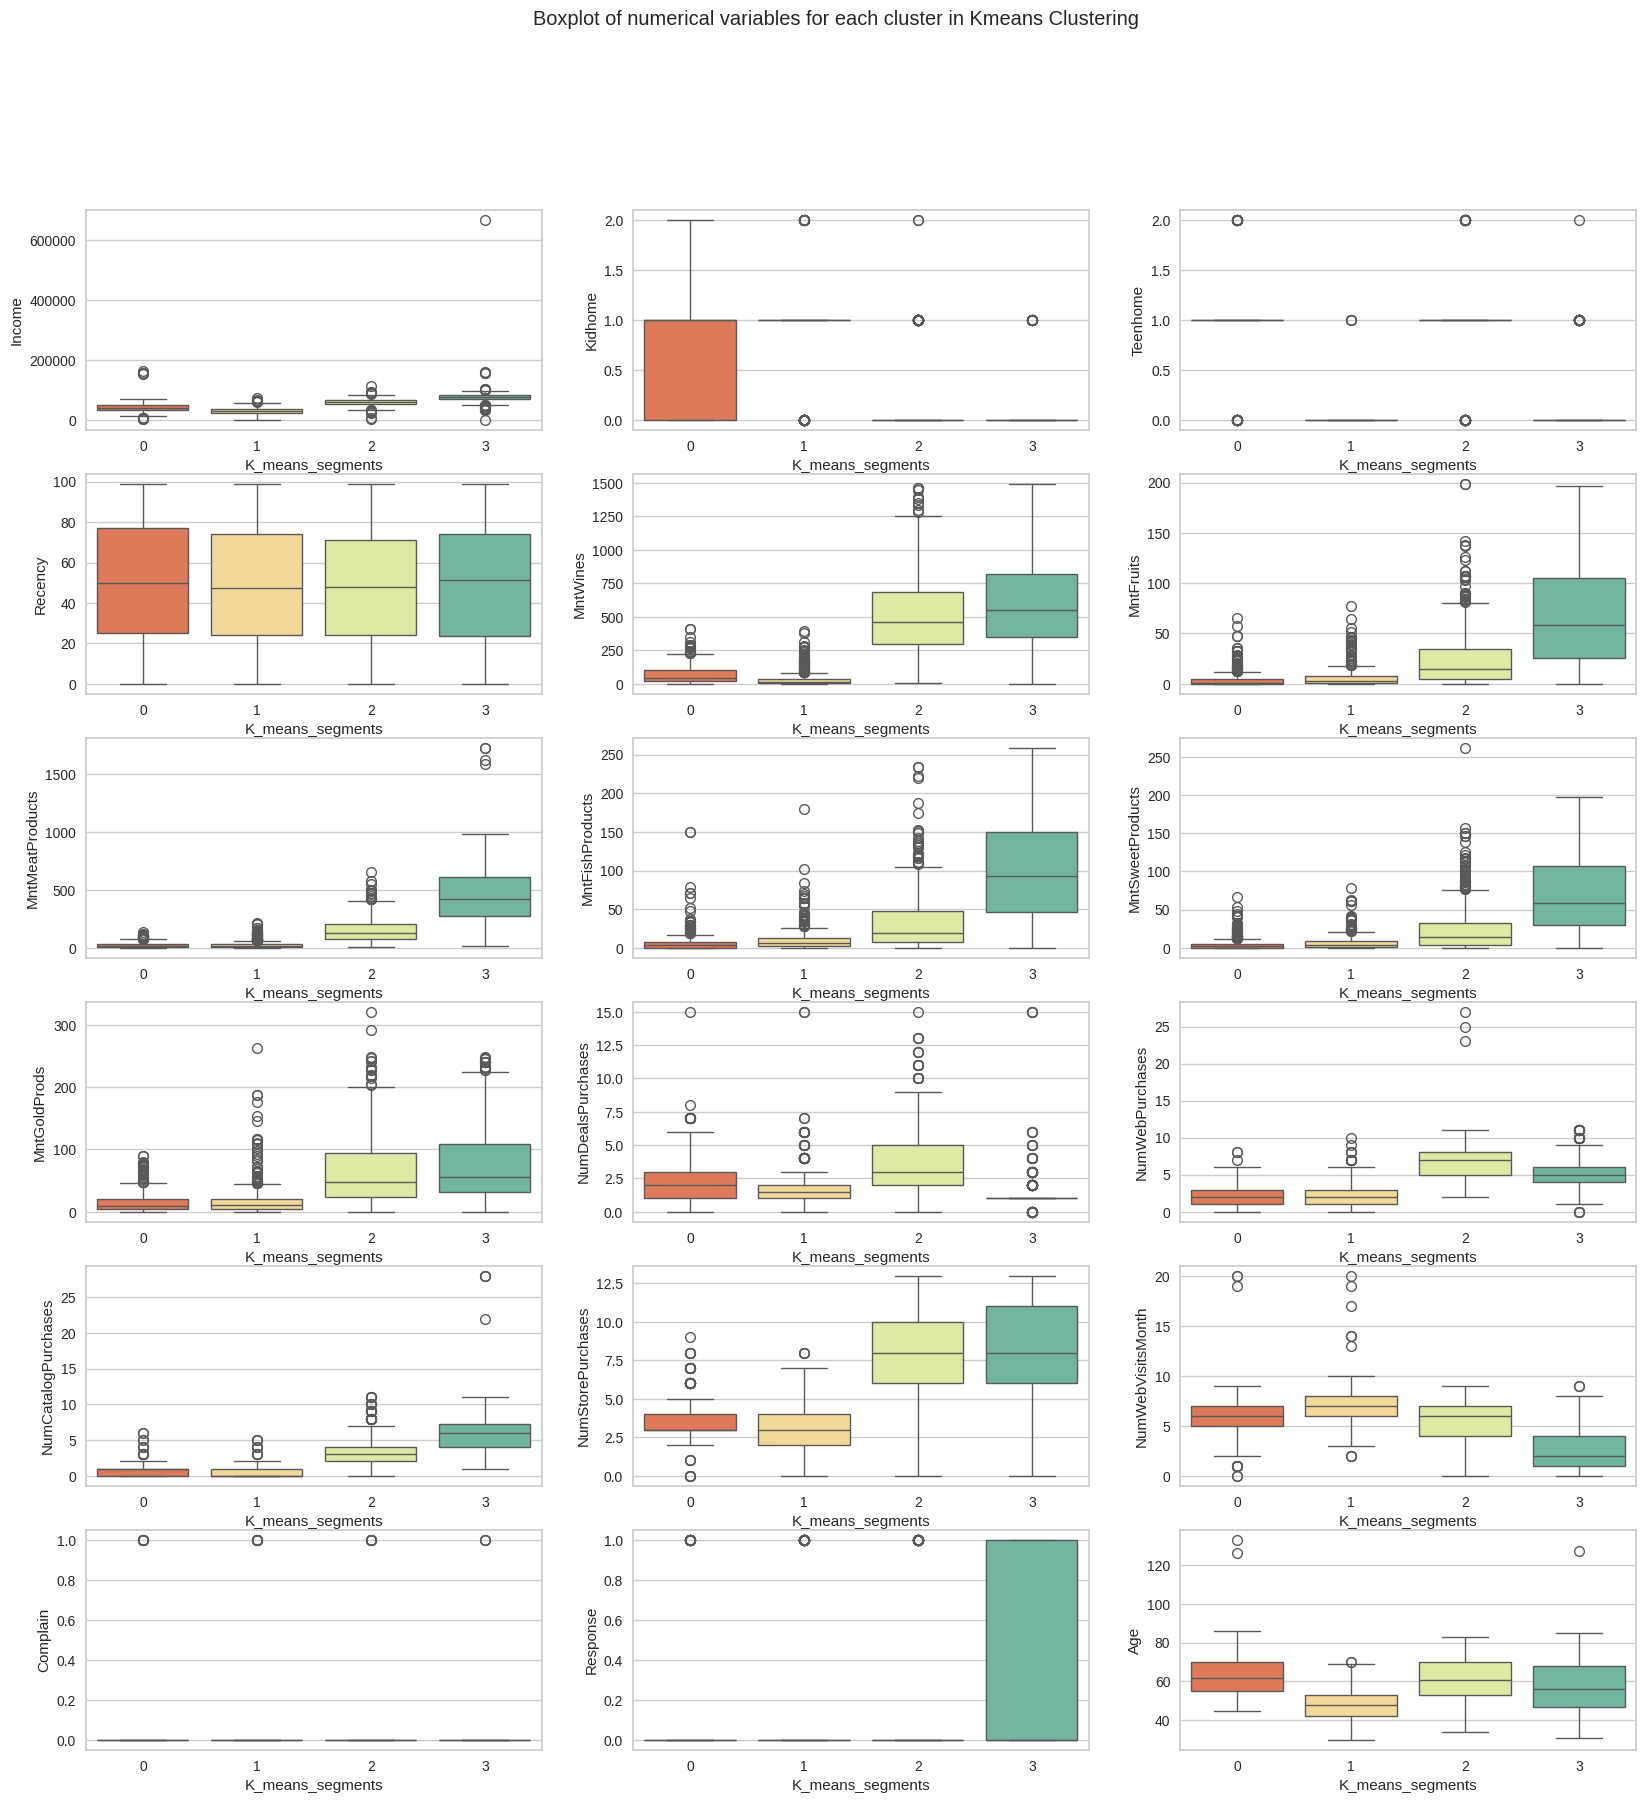

In [35]:
plt.figure(figsize=(20, 20))  # Set the figure size for the plot
plt.suptitle("Boxplot of numerical variables for each cluster in Kmeans Clustering")  # Set the main title for the plot

# Iterate over each numerical variable in the dataframe
for i, variable in enumerate(data1.columns.to_list()[:-1]):
    plt.subplot(6, 3, i + 1)  # Create subplots in a 3x4 grid, starting from index 1
    sns.boxplot(data=data1, x="K_means_segments", y=variable, palette='Spectral') # Hint: X = clusters, Y = columns.

#### **Observations from Cluster Profiling using Boxplots:**
- **Cluster 0 - Moderate Budget Shoppers:** This group has lower income levels and the lowest spending across luxury categories like Wine and Meat. They show high engagement with the company website but low conversion into high-value purchases.
- **Cluster 1 - High Spenders:** This is the most profitable segment with high income and significantly higher spending on Wines and Meat. They prefer shopping through catalogs and stores rather than using deals.
- **Cluster 2 - Value-Seeking Families:** This segment is characterized by having the highest number of children and teenagers at home. Their spending is moderate and they are the most likely to use discounts for their purchases.
- **Cluster 3 - Stable Balanced Customers:** These customers have mid-range income and show consistent spending patterns across most categories. They are frequent store shoppers and maintain a steady relationship with the brand.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

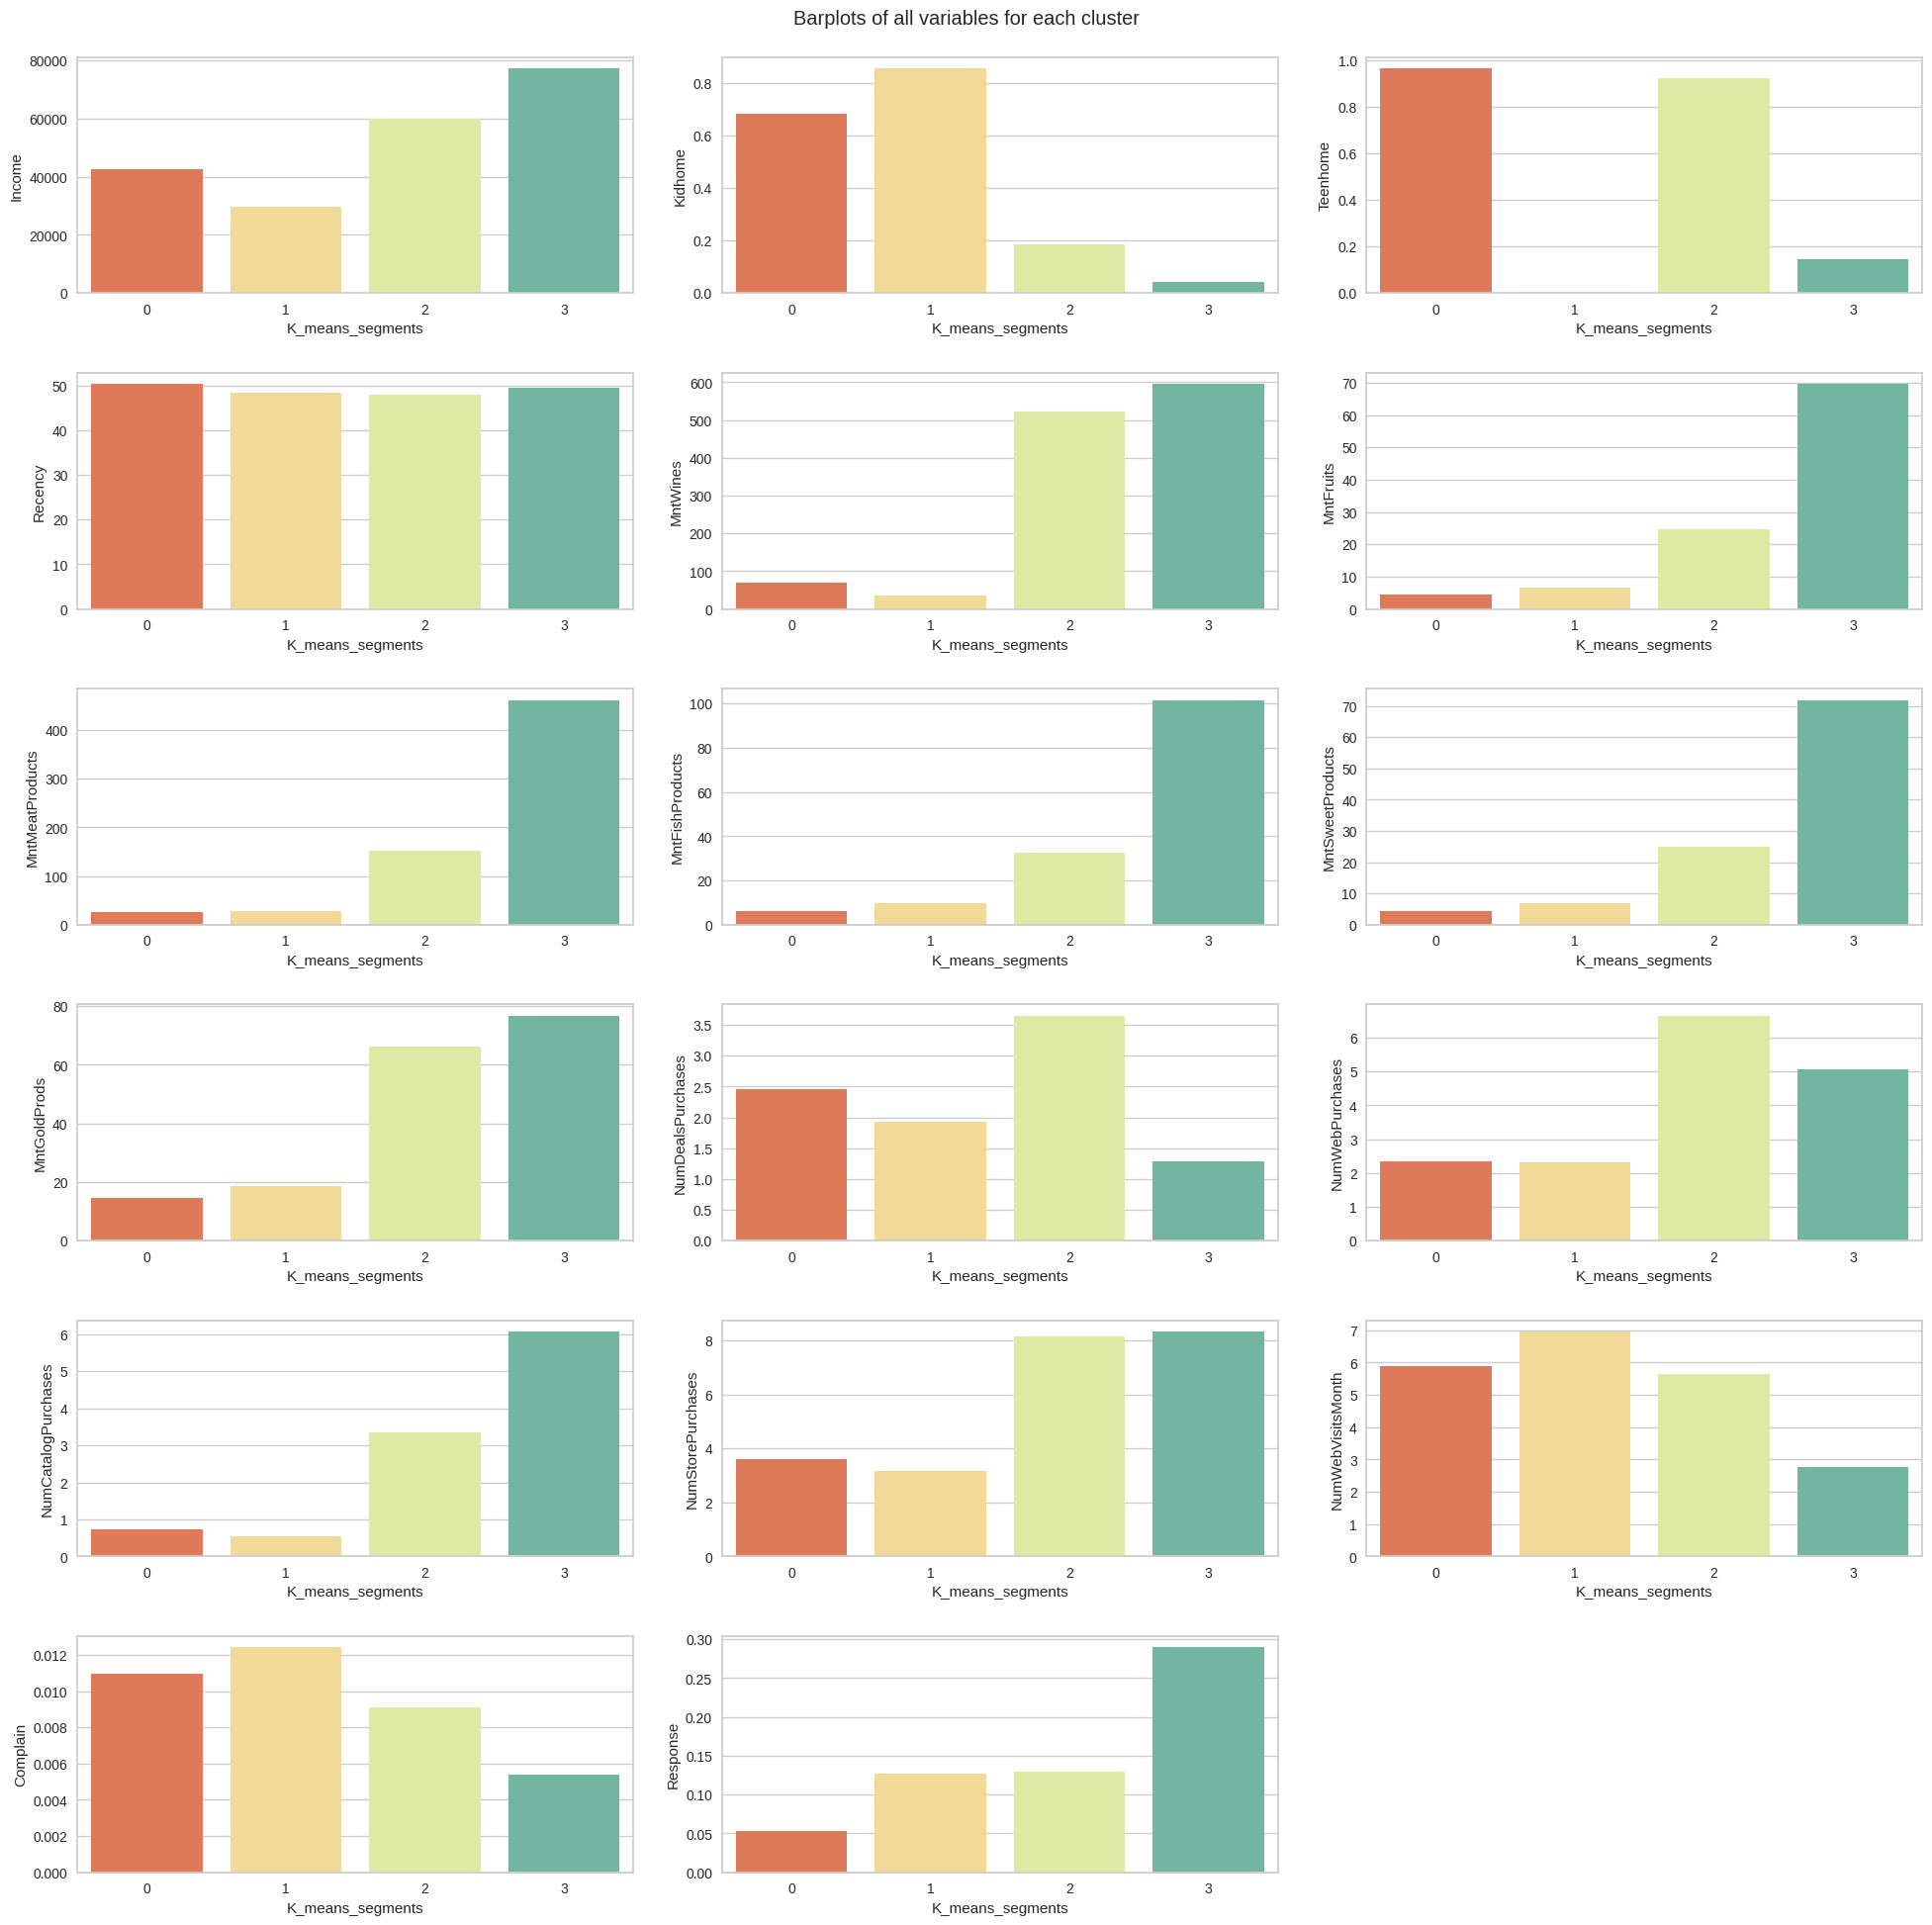

In [38]:
# Prepare for plotting barplots of numerical variables for each cluster
plt.figure(figsize=(20, 20))  # Set the figure size for the plot
plt.suptitle("Barplots of all variables for each cluster")  # Set the main title for the plot

for i, variable in enumerate(data.columns.to_list()[:-1]):
    plt.subplot(6, 3, i + 1)
    sns.barplot(data=data1, x="K_means_segments", y=variable, palette='Spectral', errorbar=None)

plt.tight_layout(pad=2.0)

#### **Observations from Cluster Profiling using Barplots:**
- **Income and Spending:** Cluster 1 stands out as the highest income group with the highest average spending across most product categories. Cluster 0 and Cluster 2 have the lowest average income and spending levels.
- **Campaign Response:** Cluster 1 and Cluster 3 show a higher average response to marketing campaigns compared to the other groups.
- **Shopping Preferences:** Cluster 1 is the primary driver for catalog and store purchases. Cluster 2 shows a higher reliance on deals, while Cluster 0 has the highest average for monthly web visits despite lower actual spending.
- **Household Composition:** Cluster 2 clearly shows the highest average number of children and teenagers in the household, which likely influences their deal-seeking behavior.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

### **Cluster Insights and Recommendations**

**1. High-Value Enthusiasts - Cluster 1:**
- **Profile:** This group has high income and high spending on Wines and Meat but shows low sensitivity to discounts.
- **Recommendation:** Focus on retention through a premium loyalty program and exclusive offers for high-margin products like Gold and Fine Wines.

**2. Deal-Seeking Families - Cluster 2:**
- **Profile:** These are households with children or teenagers with moderate income and high usage of deal-based purchases.
- **Recommendation:** Launch targeted Family-Sized promotions and discount coupons delivered via email to drive volume.

**3. Opportunity and Low Spenders - Cluster 0:**
- **Profile:** This segment has lower income and frequent web visits but low conversion to high spending.
- **Recommendation:** Use Welcome discounts or limited-time offers to convert high web traffic into actual sales.

**4. Balanced Shoppers - Cluster 3:**
- **Profile:** These customers have mid-range spending across various categories with a preference for store purchases.
- **Recommendation:** Enhance the in-store experience and offer Buy Online Pick Up In Store BOPIS incentives to maintain their steady purchasing habits.

**Presentation**




# **Business Presentation: Customer Personality Segmentation**

### **Slide 1: Project Overview and Objective**
- **Business Context:** Competition is intensifying in the retail space. Moving from generic to personalized marketing is essential.
- **Objective:** Identify distinct customer segments to optimize marketing efficiency, improve retention, and allocate resources effectively.

### **Slide 2: Data Overview and Preprocessing**
- **Dataset:** 2,240 customer records with 30 attributes including demographics, spending, and purchase behavior.
- **Cleaning:** Handled missing values in Income and dropped irrelevant columns for clustering.
- **Preparation:** Features were scaled using StandardScaler to ensure the K-Means algorithm performs optimally.

### **Slide 3: Identifying Optimal Clusters**
- **Methodology:** Used the Elbow Method and Silhouette Scores to determine the best fit.
- **Result:** 4 distinct clusters were identified as the optimal balance between complexity and segment distinctness.

### **Slide 4: Segment 1 Profile - High-Value Enthusiasts**
- **Characteristics:** High income and highest spending on Wines and Meat. Prefer Store and Catalog purchases.
- **Behavior:** Low sensitivity to discounts and marketing campaigns.
- **Strategy:** Focus on premium loyalty programs and exclusive product access.

### **Slide 5: Segment 2 Profile - Deal-Seeking Families**
- **Characteristics:** Households with the highest number of children and teenagers. Moderate income.
- **Behavior:** High reliance on discounts and deals for purchases.
- **Strategy:** Targeted family-sized promotions and discount coupons delivered via email.

### **Slide 6: Segment 3 Profile - Opportunity and Low Spenders**
- **Characteristics:** Lower income levels and lowest spending in luxury categories.
- **Behavior:** High website traffic (web visits) but low conversion into high-value sales.
- **Strategy:** Use 'Welcome' discounts and limited-time offers to convert browsers into buyers.

### **Slide 7: Segment 4 Profile - Balanced Shoppers**
- **Characteristics:** Mid-range income and consistent spending across most categories.
- **Behavior:** Frequent store shoppers with a stable relationship with the brand.
- **Strategy:** Enhance in-store experience and offer Buy Online Pick Up In Store incentives.

### **Slide 8: Strategic Business Recommendations**
- **Personalization:** Tailor marketing campaigns based on the specific spending triggers of each cluster.
- **Retention:** Prioritize high-value retention for Cluster 1.
- **Efficiency:** Allocate more resources to Store and Web channels where engagement is highest for the balanced and opportunity segments.

# **Business Presentation: Customer Personality Segmentation**

### **Slide 1: Contents / Agenda**
- Business Problem Overview
- Data Overview
- EDA - Univariate Analysis
- EDA - Multivariate Analysis
- K-Means Clustering
- Cluster Profiling and Analysis
- Business Recommendations

### **Slide 2: Business Problem Overview**
- **Business Context:** Understanding customer behavior is pivotal for enhancing satisfaction and revenue. A leading retail company seeks deeper insights into customer profiles to unlock personalization opportunities and sustain a competitive edge in an intensifying market.
- **The Challenge:** Moving away from generic strategies to targeted approaches is essential for fostering long-term relationships and improving campaign effectiveness.
- **Objective:** Identify distinct customer segments to develop personalized marketing campaigns and increase conversion rates. Create effective retention strategies for high-value groups and optimize resource allocation such as inventory and pricing.
- **Responsibility:** Analyze customer data using machine learning to provide actionable insights into the unique characteristics of each identified segment.

### **Slide 3: Data Overview**
- **Dataset:** 2240 records with attributes covering demographics, spending categories, and purchase channels.
- **Q1 Data Types:** Mostly numerical integers and floats, with three object columns for Education, Marital Status, and Enrollment Date.
- **Q2 Average Income:** The average household income is approximately $52,247.
- **Q3 Missing Values:** Only the Income column had missing data, specifically 24 null values which were handled before analysis.
- **Q4 Duplicates:** Checked for duplicate records and confirmed there are 0 identical rows in the dataset.

### **Slide 4: EDA - Univariate Analysis**
- **Question 5 Summary:** Performed a full distribution check on all 18 variables using Histograms and Boxplots.
- **Demographics:** Income and Age are roughly normally distributed, though Income has extreme high-end outliers.
- **Spending Categories:** All spending variables like Wines, Fruits, Meat, Fish, Sweets, and Gold show strong right-skewed distributions, indicating a small number of high-value shoppers.
- **Purchase Channels:** Store purchases are the primary channel for most customers, followed by Web purchases. Catalog purchases have the lowest frequency across the board.
- **Website Engagement:** Most customers visit the website 5 to 7 times per month, regardless of their actual spending level.
- **[NOTE: Include screenshots of Histograms from cell P6EifOtXlbh3 and Boxplots from cell ndFe6Y9uD1e6]**

### **Slide 5: EDA - Multivariate Analysis**
- **Question 6 Summary:** Explored relationships between variables using a correlation heatmap and pairplots.
- **Income and Spending:** Strongest positive correlation observed between Income and high-end categories like MntWines and MntMeatProducts.
- **Family Dynamics:** Negative correlations found between the number of children/teenagers at home and spending on luxury items like Wine.
- **Purchase Channels:** Positive correlation between Store, Web, and Catalog purchases suggests that high-value customers engage across all available channels.
- **Web Visits:** Interestingly, web visits show a negative correlation with actual spending, suggesting lower-income customers browse more frequently without purchasing.
- **[NOTE: Include screenshot of the Heatmap from cell OsYlhCxDMVwx]**

### **Slide 6: K-Means Clustering**
- **Q7 Elbow Method:** Analyzed the WCSS for k-values 2 through 10. A distinct elbow was observed at k=4, indicating an optimal point for cluster separation.
- **Q8 Silhouette Scores:** Validated the number of clusters using silhouette scores. While k=2 had the highest score, k=4 provided a better balance between mathematical distinctness and actionable business segmentation.
- **Q9 Final Fit:** The final model with 4 clusters was fitted to the scaled data with an execution time of approximately 9 milliseconds, demonstrating high computational efficiency.
- **[NOTE: Include screenshots of the Elbow Plot from cell 7_ewfhqbMVw8 and Silhouette Plot from cell RmHZYprwMVw8]**

### **Slide 7: Cluster Profiling and Analysis**
- **Question 10 & 11 Summary:** Profiles were created using Boxplots and Barplots to compare averages and distributions across segments.
- **Cluster 1 High Spenders:** High income and heavy spending on Wine. Low deal sensitivity. Prefer Catalog and Store shopping.
- **Cluster 2 Budget Families:** Households with high numbers of children who rely heavily on discounts and deals. Lower luxury spending.
- **Cluster 0 Opportunity Segment:** Frequent web visitors with low conversion rates and lower income. High interest but low current spend.
- **Cluster 3 Balanced Shoppers:** Mid-range income with steady, balanced purchasing habits across all channels and categories.
- **[NOTE: Include screenshots of the Segmented Boxplots from cell 4n4rdw46MVxC and Segmented Barplots from cell IhDruHburkmt]**

### **Slide 8: Business Recommendations**
- **Question 12 Summary:** Strategic recommendations based on unique cluster triggers and behaviors.
- **Retention:** Create a premium loyalty club for Cluster 1 to secure high-margin sales.
- **Promotions:** Launch family-sized bundle deals for Cluster 2 via email campaigns.
- **Conversion:** Use first-purchase discount codes to turn Cluster 0 web traffic into actual revenue.
- **Convenience:** Promote Buy Online Pick Up In Store services to retain the balanced shoppers in Cluster 3.